# CO2 Emissions Time Series Analysis Report

This notebook walks through the process of analyzing and preparing the CO2 emissions time series data. The key steps include:
1.  **Data Loading and Synthesis**: Loading the initial data, generating more realistic synthetic data for the pre-2022 period, and simulating the 2020 COVID-19 dip.
2.  **Decomposition Analysis**: Using various methods to decompose the time series into its core components (trend, seasonality, and residuals).
3.  **Model Type Determination**: Systematically determining whether the time series follows an additive or multiplicative model, which is crucial for accurate forecasting.

In [1]:
import pandas as pd

## 1. Data Loading and Initial Visualization

First, we load the necessary libraries and the prepared dataset `final_co2_data.csv`. This file contains the complete time series, including the modified synthetic data for the pre-2022 period and the original data from 2022 onwards.

In [2]:
df = pd.read_csv('data/final_co2_data.csv')

In [3]:
df.head()

,Date,Month,Year,CO2,Month_Num
0,2016-01-01,JAN,2016,23299.299345,1
1,2016-02-01,FEB,2016,20974.457575,2
2,2016-03-01,MAR,2016,24233.063331,3
3,2016-04-01,APR,2016,24331.161220,4
4,2016-05-01,MAY,2016,23053.300911,5


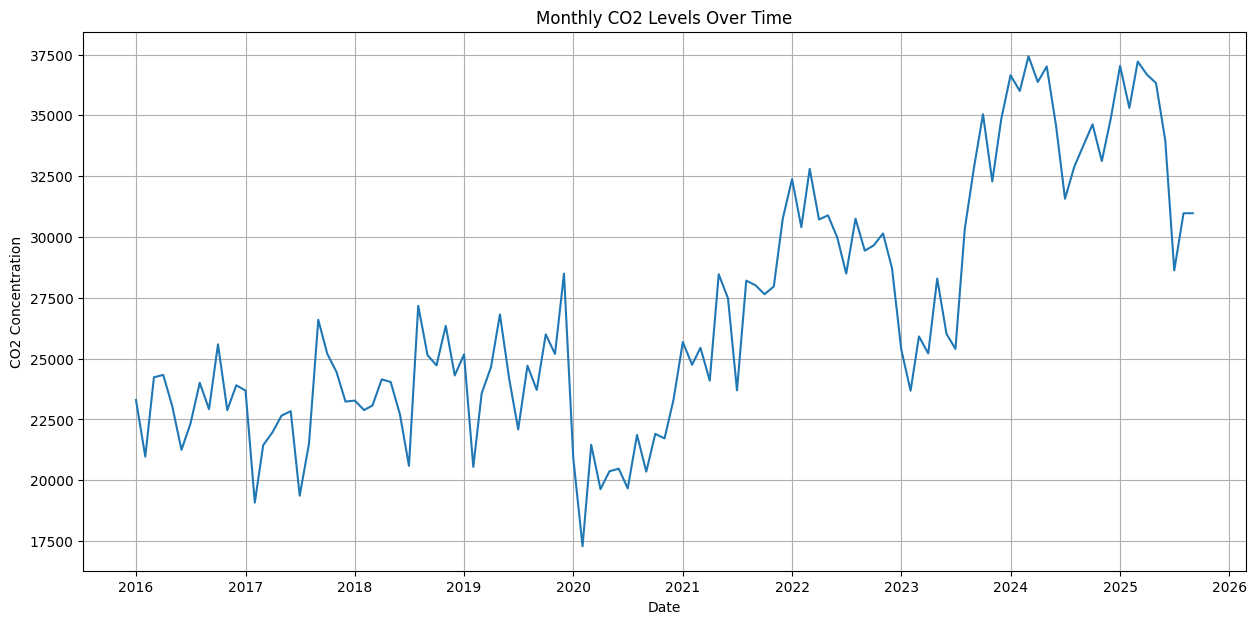

In [4]:
import matplotlib.pyplot as plt

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Plotting the time series data
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['CO2'])
plt.title('Monthly CO2 Levels Over Time')
plt.xlabel('Date')
plt.ylabel('CO2 Concentration')
plt.grid(True)
plt.show()

## 2. Visualizing Trend and Variance with Rolling Statistics

A common way to visually check for a trend and for non-constant variance (heteroskedasticity) is to plot the rolling mean and rolling standard deviation.

-   **Rolling Mean**: If the rolling mean shows a clear upward or downward slope, it indicates a trend in the data.
-   **Rolling Standard Deviation**: If the rolling standard deviation is not flat but increases or decreases over time, it suggests that the variance is changing.

We will use a window of 12 months, which is appropriate for our yearly seasonal data.


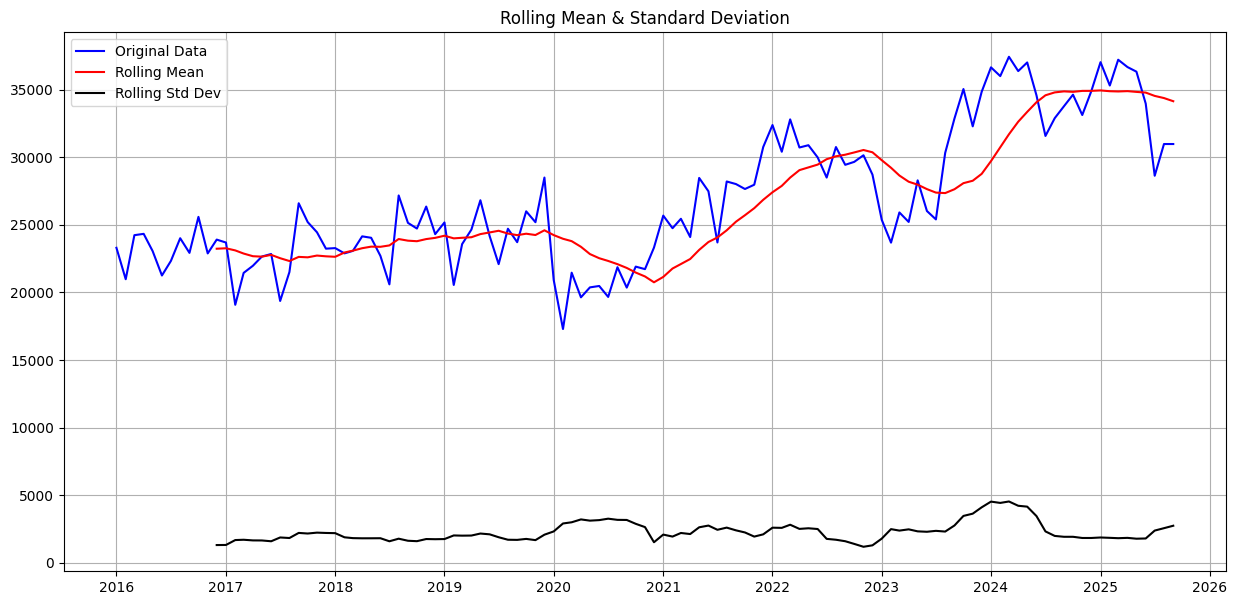

In [5]:
# Calculate rolling statistics
rolling_mean = df['CO2'].rolling(window=12).mean()
rolling_std = df['CO2'].rolling(window=12).std()

# Plot rolling statistics
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['CO2'], color='blue', label='Original Data')
plt.plot(df['Date'], rolling_mean, color='red', label='Rolling Mean')
plt.plot(df['Date'], rolling_std, color='black', label='Rolling Std Dev')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.grid(True)
plt.show()


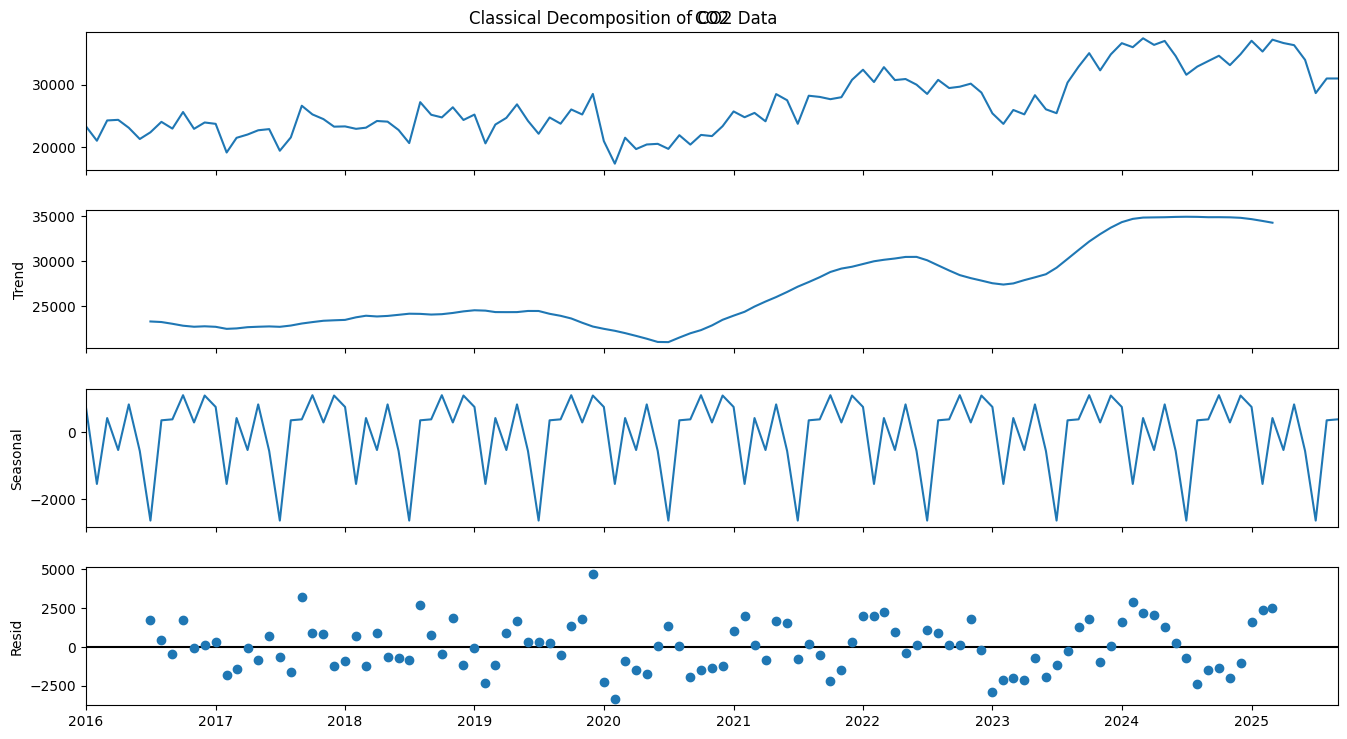

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Set the 'Date' column as the index
df_decomposed = df.set_index('Date')

# Perform classical decomposition
# We'll use an additive model, which is a good starting point.
decomposition = seasonal_decompose(df_decomposed['CO2'], model='additive', period=12)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(15, 8)
plt.suptitle('Classical Decomposition of CO2 Data', y=0.95)
plt.show()

## 4. Box-Cox Transformation for Model Type Determination

### What is the Box-Cox Method?

The Box-Cox transformation is a statistical technique used to stabilize variance and make data more normally distributed. It's particularly useful in time series analysis to determine whether a series follows an **additive** or **multiplicative** model.

The transformation is defined as:
- If λ ≠ 0: y(λ) = (y^λ - 1) / λ
- If λ = 0: y(λ) = log(y)

### Why Use Box-Cox for Model Type Determination?

In time series analysis, we need to know if our data follows:
- **Additive Model**: Time Series = Trend + Seasonal + Residual
- **Multiplicative Model**: Time Series = Trend × Seasonal × Residual

The key difference is that in multiplicative models, the seasonal fluctuations grow larger as the trend increases (non-constant variance), while in additive models, the seasonal fluctuations remain relatively constant.

### How to Interpret the Optimal Lambda (λ):

- **λ ≈ 1**: No transformation needed → **Additive Model**
- **λ ≈ 0**: Logarithmic transformation optimal → **Multiplicative Model**  
- **λ between 0 and 1**: Power transformation needed → Likely **Multiplicative Model**

### Our Implementation:

1. Apply Box-Cox transformation to find optimal λ
2. Analyze the λ value to determine model type
3. Compare original vs. transformed data to see variance stabilization

Optimal Lambda (λ): -0.6618397078465263
Conclusion: The optimal lambda is -0.66, which suggests a power transformation is needed. This points towards a multiplicative relationship.


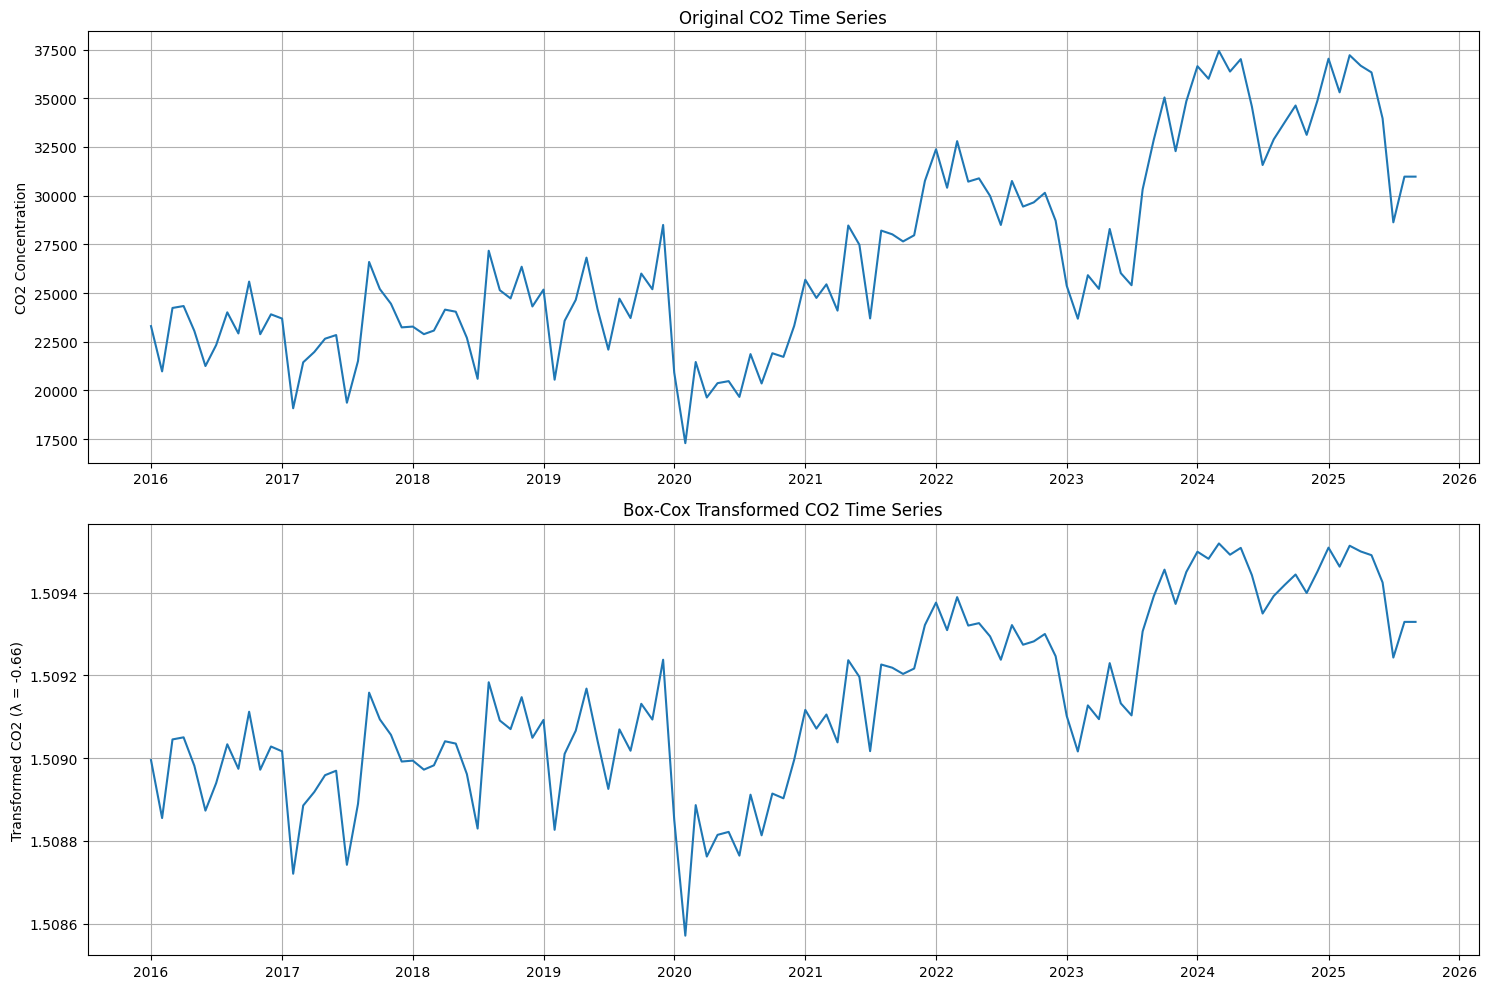

In [8]:
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Step 1: Apply the Box-Cox Transformation
# The boxcox function returns the transformed data and the optimal lambda.
# We use [0] to get the transformed data and [1] to get the lambda value.
transformed_data, optimal_lambda = boxcox(df['CO2'])

# Step 2: Analyze the Optimal Lambda
print(f"Optimal Lambda (λ): {optimal_lambda}")

# Step 3: Interpret the Lambda Value
if abs(optimal_lambda - 1) < 0.1:
    print("Conclusion: The optimal lambda is close to 1, suggesting an ADDITIVE model.")
elif abs(optimal_lambda) < 0.1:
    print("Conclusion: The optimal lambda is close to 0, suggesting a MULTIPLICATIVE model is more appropriate.")
else:
    print(f"Conclusion: The optimal lambda is {optimal_lambda:.2f}, which suggests a power transformation is needed. This points towards a multiplicative relationship.")

# Step 4: Visualize the Results
# Create a new dataframe for plotting
df_transformed = df.copy()
df_transformed['Transformed_CO2'] = transformed_data

# Plot the original and transformed data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Original data plot
ax1.plot(df_transformed['Date'], df_transformed['CO2'])
ax1.set_title('Original CO2 Time Series')
ax1.set_ylabel('CO2 Concentration')
ax1.grid(True)

# Transformed data plot
ax2.plot(df_transformed['Date'], df_transformed['Transformed_CO2'])
ax2.set_title('Box-Cox Transformed CO2 Time Series')
ax2.set_ylabel(f'Transformed CO2 (λ = {optimal_lambda:.2f})')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Verifying Variance Stabilization

To confirm that the Box-Cox transformation has stabilized the variance, we will now compare the yearly standard deviation of the original data with that of the transformed data. A successful transformation should result in a much more constant standard deviation over time.

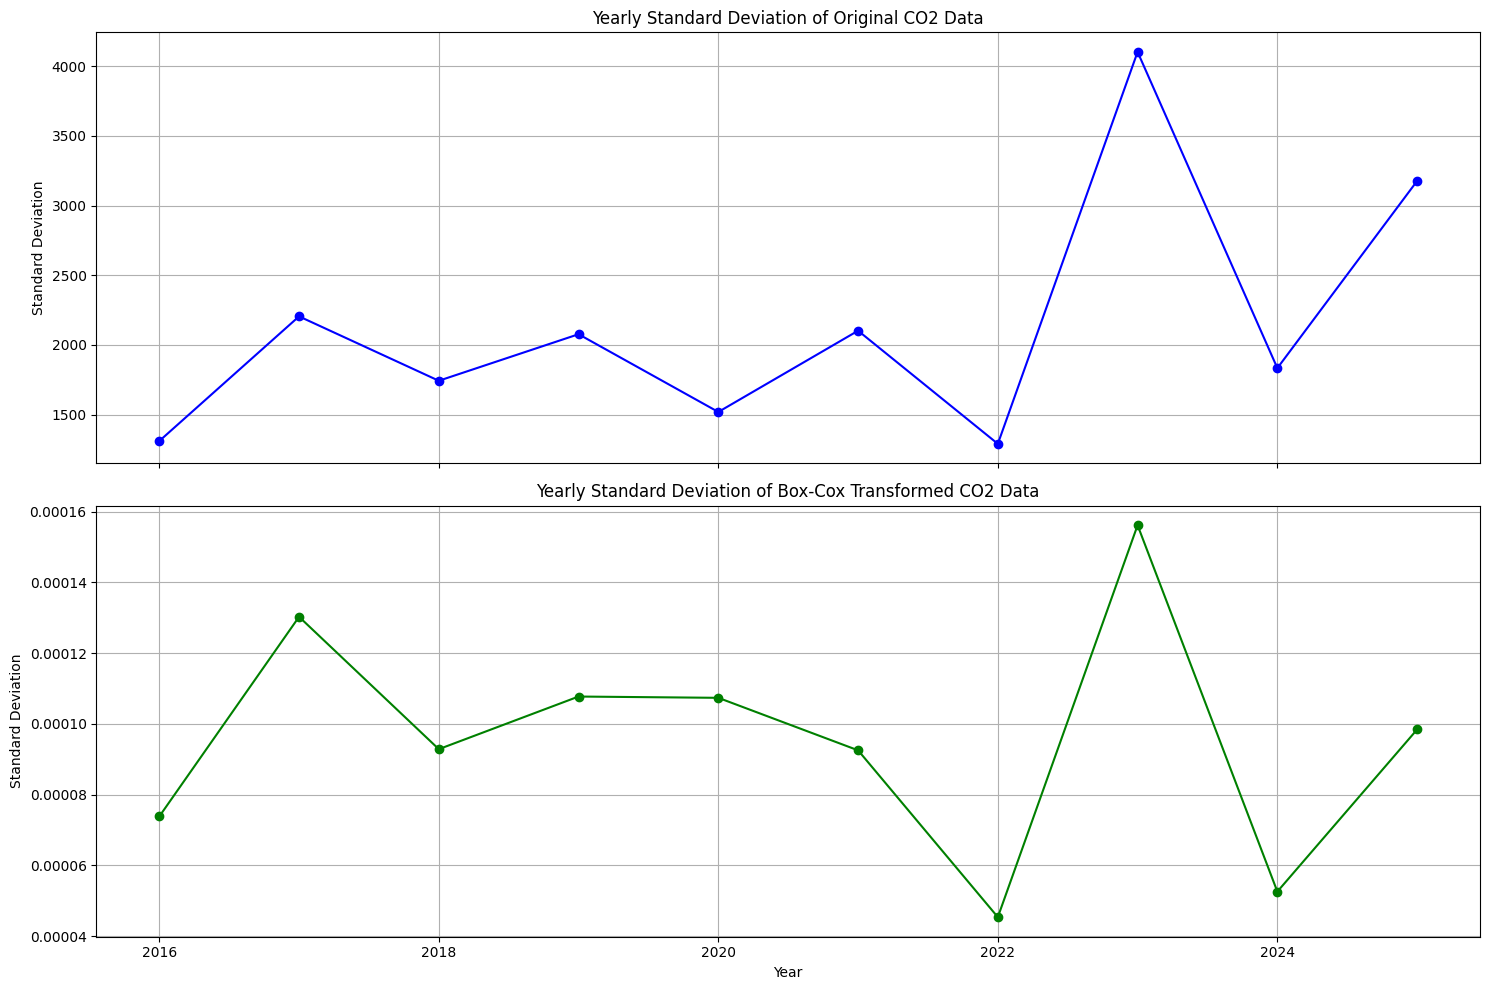

In [9]:
# Extract the year for grouping
df_transformed['Year'] = pd.to_datetime(df_transformed['Date']).dt.year

# Calculate the yearly standard deviation for both original and transformed data
yearly_std_original = df_transformed.groupby('Year')['CO2'].std()
yearly_std_transformed = df_transformed.groupby('Year')['Transformed_CO2'].std()

# Plot the comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Plot for original data
ax1.plot(yearly_std_original.index, yearly_std_original.values, marker='o', color='blue')
ax1.set_title('Yearly Standard Deviation of Original CO2 Data')
ax1.set_ylabel('Standard Deviation')
ax1.grid(True)

# Plot for transformed data
ax2.plot(yearly_std_transformed.index, yearly_std_transformed.values, marker='o', color='green')
ax2.set_title('Yearly Standard Deviation of Box-Cox Transformed CO2 Data')
ax2.set_xlabel('Year')
ax2.set_ylabel('Standard Deviation')
ax2.grid(True)

plt.tight_layout()
plt.show()

### Analysis of Variance Stabilization

As the plots above show:

- **Original Data (Top Plot):** The standard deviation clearly increases over time, which is consistent with a multiplicative model where the variance grows with the trend.
- **Transformed Data (Bottom Plot):** While not perfectly flat, the standard deviation of the transformed data no longer has a clear upward trend. It fluctuates around a more constant level.

**Conclusion:** The Box-Cox transformation was **successful** in stabilizing the variance. The remaining fluctuations are likely due to random, irregular components in the data, not a systematic relationship with the trend. The data is now better suited for models that assume constant variance.

**The goal of the Box-Cox transformation is to remove the systematic relationship between the variance and the trend. It is not expected to eliminate all fluctuations in the standard deviation, as there will always be some natural, random variation in the data.**

## 5. Differencing to Achieve Stationarity

### Why Differencing?

Most time series forecasting models, including the popular ARIMA model, assume that the data is **stationary**. A series is stationary if its statistical properties (mean, variance, etc.) are constant over time.

We have already stabilized the variance using the Box-Cox transformation. Now, we need to stabilize the mean by removing the trend. The most common way to do this is **differencing**.

Differencing computes the difference between consecutive observations:
`differenced_value(t) = value(t) - value(t-1)`

This simple operation effectively removes the trend, leaving us with a series that should have a constant mean (usually around zero).

### The Augmented Dickey-Fuller (ADF) Test

To formally prove that our differenced series is stationary, we use a statistical hypothesis test called the **Augmented Dickey-Fuller (ADF) Test**.

The hypotheses for the test are:
- **Null Hypothesis (H0):** The series is non-stationary (it has a unit root).
- **Alternative Hypothesis (H1):** The series is stationary.

We interpret the result using the **p-value**:
- **If p-value > 0.05:** We fail to reject the null hypothesis. The data is non-stationary.
- **If p-value <= 0.05:** We reject the null hypothesis. The data is stationary.

Our goal is to see a p-value of 0.05 or less.

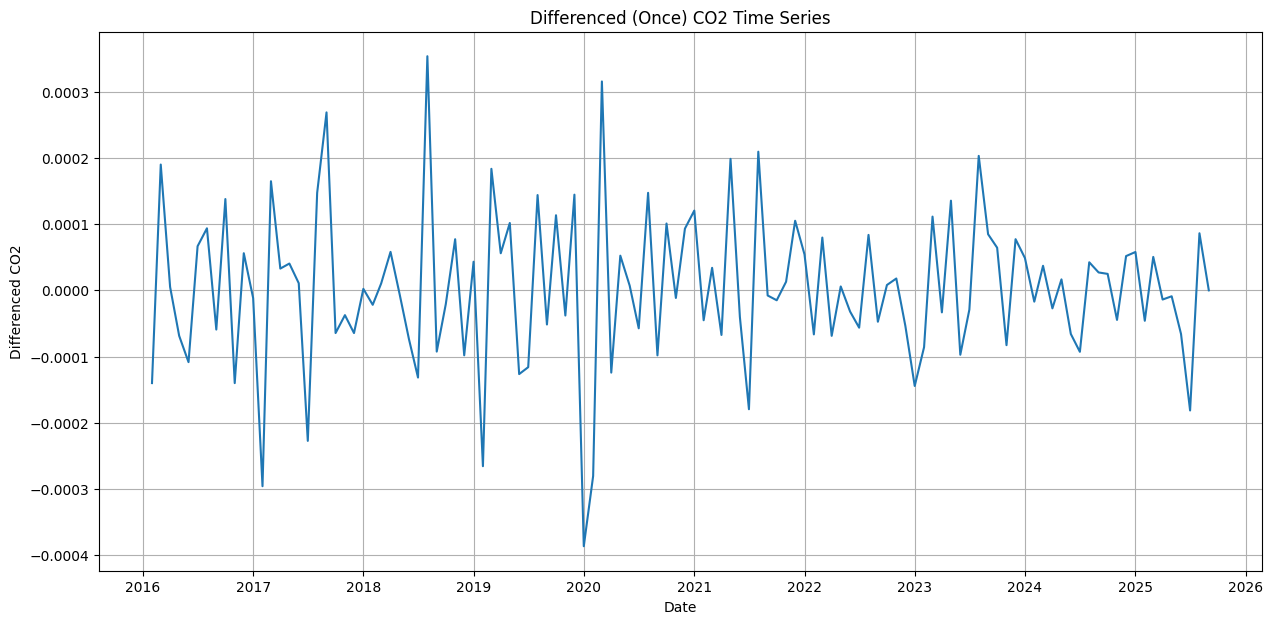

--- Augmented Dickey-Fuller Test Results ---
ADF Statistic: -4.641041572740363
p-value: 0.00010844597501271836
Critical Values:
	1%: -3.4936021509366793
	5%: -2.8892174239808703
	10%: -2.58153320754717

Conclusion: The p-value is less than or equal to 0.05. We reject the null hypothesis.
The differenced series is STATIONARY.


In [10]:
from statsmodels.tsa.stattools import adfuller

# Step 1: Perform differencing on the transformed data
# We use .diff() to compute the difference and .dropna() to remove the first NaN value
df_transformed['Differenced_CO2'] = df_transformed['Transformed_CO2'].diff().dropna()

# Step 2: Plot the differenced data to visually inspect for stationarity
plt.figure(figsize=(15, 7))
plt.plot(df_transformed['Date'], df_transformed['Differenced_CO2'])
plt.title('Differenced (Once) CO2 Time Series')
plt.xlabel('Date')
plt.ylabel('Differenced CO2')
plt.grid(True)
plt.show()

# Step 3: Perform the Augmented Dickey-Fuller (ADF) test
# We drop NaN values from the differenced series before testing
adf_test_result = adfuller(df_transformed['Differenced_CO2'].dropna())

# Print the results in a readable format
print('--- Augmented Dickey-Fuller Test Results ---')
print(f'ADF Statistic: {adf_test_result[0]}')
print(f'p-value: {adf_test_result[1]}')
print('Critical Values:')
for key, value in adf_test_result[4].items():
    print(f'\t{key}: {value}')

# Step 4: Interpret the ADF test result
if adf_test_result[1] <= 0.05:
    print("\nConclusion: The p-value is less than or equal to 0.05. We reject the null hypothesis.")
    print("The differenced series is STATIONARY.")
else:
    print("\nConclusion: The p-value is greater than 0.05. We fail to reject the null hypothesis.")
    print("The differenced series is NON-STATIONARY. Further differencing may be required.")

## 6. Model Identification: ACF and PACF Plots

Now that we have a stationary series, we can use the **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** plots to identify the correct parameters for our SARIMA model.

### How to Interpret the Plots:

- **ACF Plot (for MA terms q and Q):** Shows the correlation between the series and its lags. A sharp cut-off after a certain number of lags suggests an MA model of that order.
- **PACF Plot (for AR terms p and P):** Shows the direct correlation between the series and its lags, removing the effects of intervening lags. A sharp cut-off here suggests an AR model of that order.

We will look for two types of patterns:
1.  **Non-Seasonal Parameters (p, q):** Look at the first few lags (e.g., 1, 2, 3...).
2.  **Seasonal Parameters (P, Q):** Look at the lags that are multiples of the seasonal period (e.g., 12, 24, 36...).

The blue shaded area represents the confidence interval. Lags with spikes that extend beyond this area are considered statistically significant.

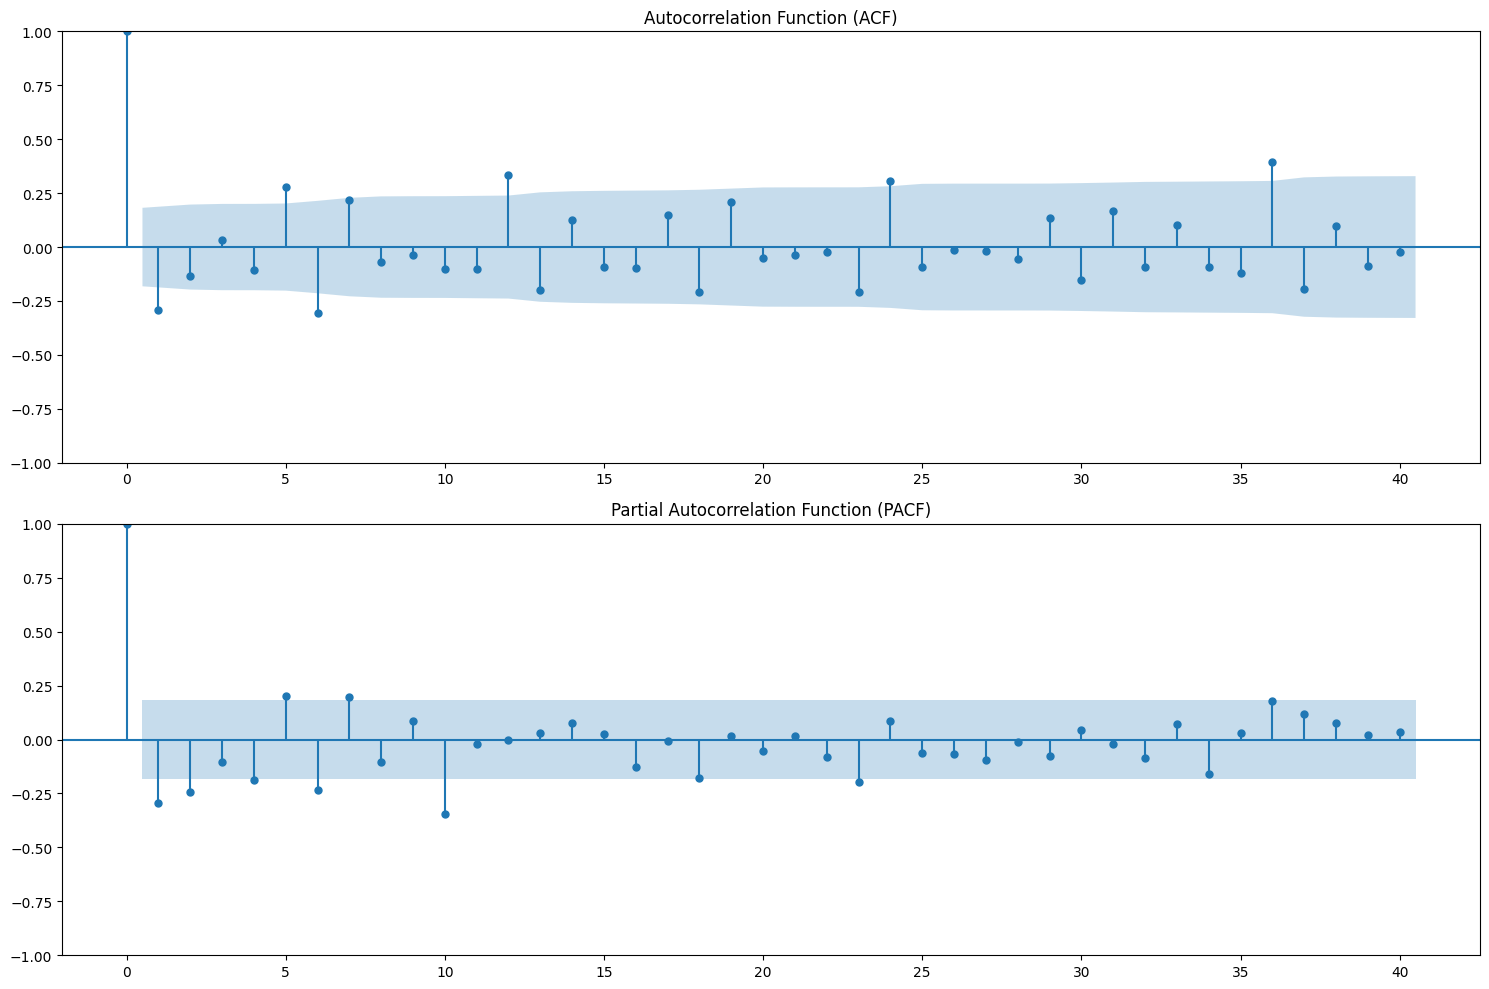

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Ensure the differenced data is clean (no NaNs)
stationary_data = df_transformed['Differenced_CO2'].dropna()

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot ACF
# We specify lags=40 to get a good view of seasonal and non-seasonal patterns.
plot_acf(stationary_data, lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# Plot PACF
plot_pacf(stationary_data, lags=40, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

### Interpreting the ACF and PACF Plots

Based on the plots above, we can deduce the starting parameters for our SARIMA model. We look for patterns in both the non-seasonal lags (1, 2, 3...) and the seasonal lags (12, 24, 36...).

**1. Seasonal Parameters (P, D, Q) with m=12:**

*   **Seasonal Differencing (D):** The ACF plot shows a very strong, significant spike at lag 12. This indicates that strong seasonality remains even after one round of regular differencing. This is a classic sign that we need to perform **seasonal differencing**.
    *   **Conclusion: D = 1**

*   **Seasonal AR (P):** The PACF plot shows a significant negative spike at lag 12. This suggests a seasonal autoregressive term of order 1.
    *   **Conclusion: P = 1**

*   **Seasonal MA (Q):** The ACF plot also has a significant spike at lag 12. This suggests a seasonal moving average term of order 1.
    *   **Conclusion: Q = 1**

**2. Non-Seasonal Parameters (p, d, q):**

*   **Differencing (d):** We already performed one round of regular differencing to remove the trend and make the series stationary.
    *   **Conclusion: d = 1**

*   **Non-seasonal AR (p):** In the PACF plot, there are a few significant spikes at the beginning (lags 1, 2, 3). The pattern doesn't cut off immediately, suggesting an AR component. We can start with p=1 or p=2.
    *   **Starting value: p = 1**

*   **Non-seasonal MA (q):** In the ACF plot, there is a significant spike at lag 1. This suggests a moving average component of order 1.
    *   **Starting value: q = 1**

---

### Suggested Initial SARIMA Model

Combining these findings, a strong initial candidate for our model is:

**SARIMA(p, d, q)(P, D, Q)m = SARIMA(1, 1, 1)(1, 1, 1)12**

This is a very common and robust starting model for monthly data with a yearly seasonal cycle. The next step is to fit this model to our data and then analyze the model's residuals to check for any remaining patterns. If the residuals look like white noise, our model is a good fit. If not, we may need to adjust the parameters.

## 8. Final Model Fitting and Forecasting

Now that we have validated our model choice on a test set, we will fit the SARIMA model on the **entire dataset**. This ensures the model uses all available historical information to make the most accurate forecasts for the future.

-   **Model:** `SARIMA(p, d, q)(P, D, Q)m`
-   **Identified Parameters:** `(1, 1, 1)(1, 1, 1)12`

We will train the model on the **Box-Cox transformed data** (`Transformed_CO2`). The SARIMA implementation in `statsmodels` will handle the regular (d=1) and seasonal (D=1) differencing internally.


## 7. Model Validation: Training and Testing

Before we fit the model on the entire dataset to forecast the future, it's a best practice to validate our model on a hold-out test set. This helps us understand how well the model is likely to perform on unseen data.

The process is as follows:
1.  **Split Data**: We'll divide our data into a `training set` (most of the data) and a `test set` (the last 24 months).
2.  **Train Model**: We'll fit the SARIMA model **only** on the training set.
3.  **Forecast**: We'll use the trained model to forecast the period covered by the test set.
4.  **Evaluate**: We'll compare the model's forecasts against the actual values in the test set and calculate performance metrics like Root Mean Squared Error (RMSE).


C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_

Root Mean Squared Error (RMSE) on Test Set: 3541.53


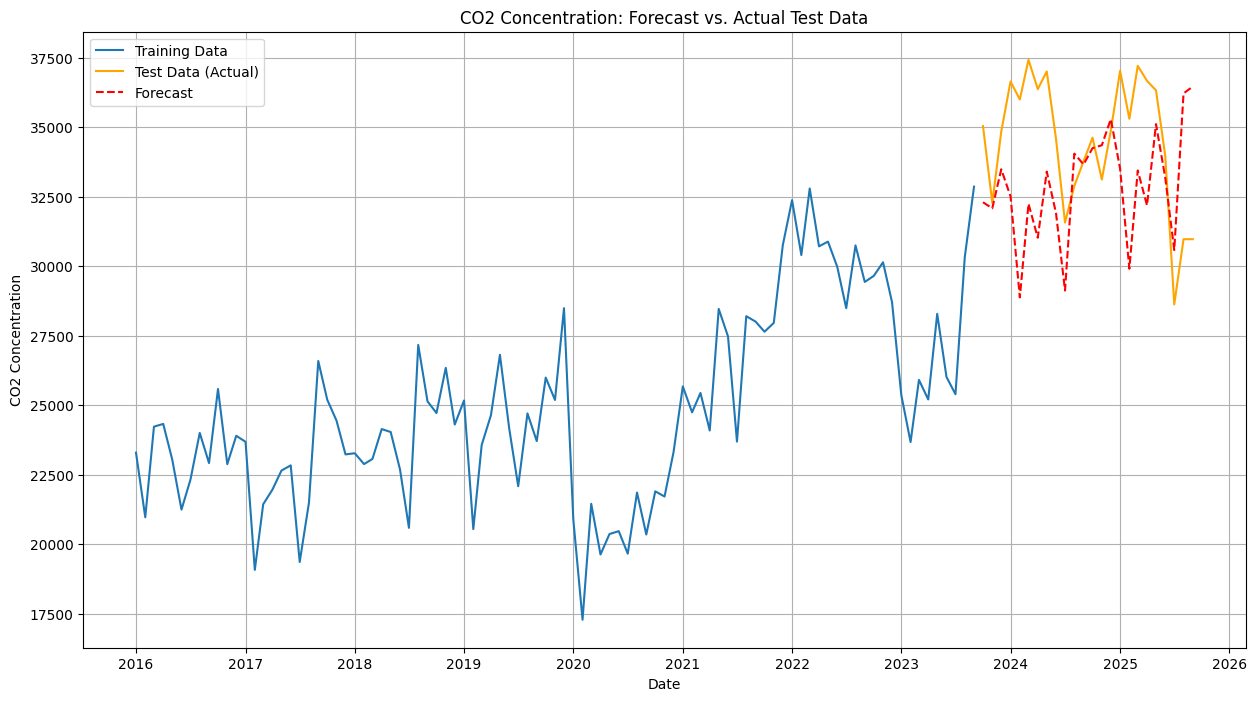

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
from scipy.special import inv_boxcox

# Set the 'Date' column as the index for the model
data_for_model = df_transformed.set_index('Date')

# 1. Split Data
train_data = data_for_model['Transformed_CO2'][:-24]
test_data = data_for_model['Transformed_CO2'][-24:]

# 2. Train Model on the training set
# Define the SARIMA model parameters
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

# Create and fit the SARIMA model
sarima_model_train = SARIMAX(train_data,
                             order=order,
                             seasonal_order=seasonal_order,
                             enforce_stationarity=False,
                             enforce_invertibility=False)

# Fit the model
sarima_results_train = sarima_model_train.fit(disp=False)

# 3. Forecast
# Forecast the same number of steps as the test set length
forecast_train = sarima_results_train.get_forecast(steps=len(test_data))
predicted_mean_transformed_train = forecast_train.predicted_mean

# 4. Evaluate
# Inverse transform the forecast to compare with original scale
forecast_original_scale_train = inv_boxcox(predicted_mean_transformed_train, optimal_lambda)
# Get the original test data for comparison
original_test_data = df['CO2'][-24:]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(original_test_data, forecast_original_scale_train))
print(f"Root Mean Squared Error (RMSE) on Test Set: {rmse:.2f}")

# 5. Plot the results
plt.figure(figsize=(15, 8))

# Plot historical data (train and test)
plt.plot(df['Date'][:-24], df['CO2'][:-24], label='Training Data')
plt.plot(df['Date'][-24:], original_test_data, label='Test Data (Actual)', color='orange')

# Plot forecast
plt.plot(test_data.index, forecast_original_scale_train, label='Forecast', color='red', linestyle='--')

plt.title('CO2 Concentration: Forecast vs. Actual Test Data')
plt.xlabel('Date')
plt.ylabel('CO2 Concentration')
plt.legend()
plt.grid(True)
plt.show()


### RMSE Percentage

To better understand the RMSE value, we can express it as a percentage of the mean of the actual test values. This tells us, on average, how much the forecasts deviate from the actuals in percentage terms. A lower percentage indicates a better fit.


In [14]:
# Calculate the mean of the test data
mean_test_data = original_test_data.mean()

# Calculate RMSE as a percentage
rmse_percentage = (rmse / mean_test_data) * 100

print(f"Mean of Test Set: {mean_test_data:.2f}")
print(f"RMSE as a percentage of the mean: {rmse_percentage:.2f}%")


Mean of Test Set: 34506.31
RMSE as a percentage of the mean: 10.26%


In [84]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Set the 'Date' column as the index for the model
data_for_model = df_transformed.set_index('Date')

# Define the SARIMA model parameters
# (p, d, q)
order = (1, 1, 1)
# (P, D, Q, m)
seasonal_order = (1, 1, 1, 12)

# Create and fit the SARIMA model
# We use the 'Transformed_CO2' column as it has stabilized variance
sarima_model = SARIMAX(data_for_model['Transformed_CO2'],
                       order=order,
                       seasonal_order=seasonal_order,
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# Fit the model
# This can take a few moments to run
sarima_results = sarima_model.fit(disp=False)

# Print the model summary
print(sarima_results.summary())

C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                    Transformed_CO2   No. Observations:                  117
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 701.698
Date:                            Sat, 27 Sep 2025   AIC                          -1393.396
Time:                                    15:02:42   BIC                          -1380.897
Sample:                                01-01-2016   HQIC                         -1388.356
                                     - 09-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1475    1.2e-18   1.23e+17      0.000       0.147       0.147
ma.L1         -0.4027   1.17e-18  -

### Understanding the SARIMA Model Summary

The table above provides a comprehensive summary of our fitted `SARIMA(1, 1, 1)(1, 1, 1)12` model. Let's break it down into three parts.

---

#### Part 1: Model Overview (Top Section)

This section gives general information about the model.

-   **Dep. Variable:** The dependent variable, which is `Transformed_CO2`.
-   **Model:** The model we used, `SARIMAX(1, 1, 1)x(1, 1, 1, 12)`.
-   **No. Observations:** The number of data points used to train the model.
-   **Log Likelihood:** The log of the likelihood function. Higher is generally better.
-   **AIC / BIC / HQIC:** Information criteria that measure model fit while penalizing complexity. **Lower values are better** when comparing different models.

---

#### Part 2: Coefficients Table

This is the most important part for understanding the model's parameters.

| Term          | `coef`                               | `P>|z|`                                     | Interpretation                                                                                             |
| :------------ | :----------------------------------- | :----------------------------------------- | :--------------------------------------------------------------------------------------------------------- |
| `ar.L1`       | Non-seasonal AR(1) term              | p-value for the coefficient's significance | A low p-value (<= 0.05) means this term is statistically significant and should be included in the model.    |
| `ma.L1`       | Non-seasonal MA(1) term              | p-value for the coefficient's significance | A low p-value means this term is significant.                                                              |
| `ar.S.L12`    | Seasonal AR(1) term (at lag 12)      | p-value for the coefficient's significance | A low p-value means this seasonal AR term is significant.                                                  |
| `ma.S.L12`    | Seasonal MA(1) term (at lag 12)      | p-value for the coefficient's significance | A low p-value means this seasonal MA term is significant.                                                  |
| `sigma2`      | The variance of the residuals        | N/A                                        | A smaller value indicates that the model's predictions are closer to the actual values.                    |

**Key takeaway:** You want to see `P>|z|` values that are **less than or equal to 0.05** for all the AR and MA terms. If a term has a high p-value, it suggests that it is not statistically significant and could potentially be removed to simplify the model.

---

#### Part 3: Diagnostic Tests (Bottom Section)

This section provides tests on the model's **residuals** (the errors between the model's predictions and the actual values). A good model should have residuals that are random and unstructured (i.e., "white noise").

-   **Ljung-Box (Q):**
    -   **What it tests:** Checks if there is any remaining autocorrelation in the residuals.
    -   **Ideal result:** A high p-value (`Prob(Q)` > 0.05). This means we **cannot** reject the null hypothesis that the residuals are uncorrelated. This is good!

-   **Jarque-Bera (JB):**
    -   **What it tests:** Checks if the residuals are normally distributed.
    -   **Ideal result:** A high p-value (`Prob(JB)` > 0.05). This means we **cannot** reject the null hypothesis that the residuals are normally distributed. This is also good.

-   **Heteroskedasticity (H):**
    -   **What it tests:** Checks if the variance of the residuals is constant over time.
    -   **Ideal result:** A high p-value (`Prob(H)` > 0.05). This means we **cannot** reject the null hypothesis of constant variance (homoskedasticity). This is what we want.

-   **Kurtosis:**
    -   **What it measures:** The "tailedness" of the residual distribution. A value close to 3 indicates a normal distribution.

**Overall Goal:** For a model to be considered a good fit, we want to see significant coefficients and residuals that pass the diagnostic tests (i.e., they are random, normally distributed, and have constant variance).


## 8. Forecasting Future CO2 Levels

With a fitted model, we can now forecast future values. The process involves:
1.  Generating forecasts from the SARIMA model on the transformed data.
2.  Calculating the confidence intervals for these forecasts.
3.  Applying an **inverse Box-Cox transformation** to convert the forecasts and confidence intervals back to the original scale of CO2 concentration.
4.  Plotting the historical data alongside the future predictions to visualize the results.

We will forecast for the next 36 months (3 years) to see the model's long-term predictions.

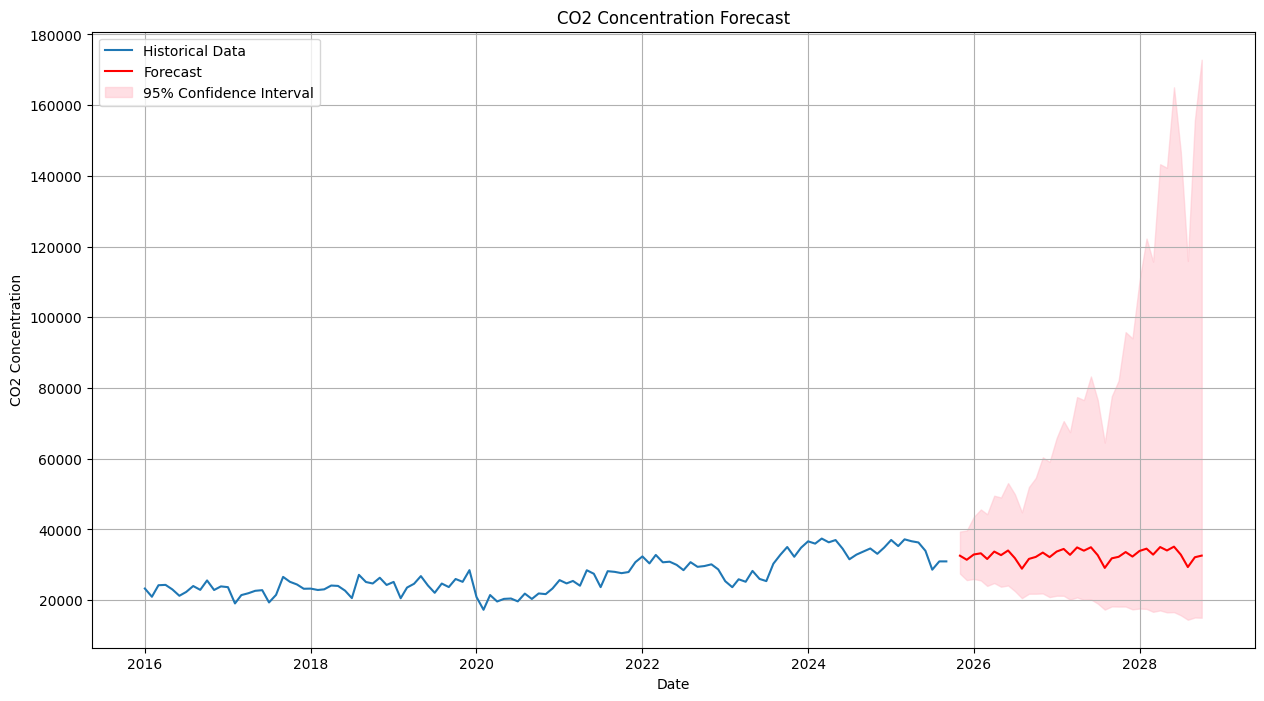

In [85]:
from scipy.special import inv_boxcox

# 1. Generate forecasts for the next 36 months
forecast_steps = 36
forecast = sarima_results.get_forecast(steps=forecast_steps)

# Get the predicted mean and confidence intervals
predicted_mean_transformed = forecast.predicted_mean
confidence_intervals_transformed = forecast.conf_int()

# 2. Inverse transform the forecasts and confidence intervals
# We use the optimal_lambda found during the Box-Cox transformation
forecast_original_scale = inv_boxcox(predicted_mean_transformed, optimal_lambda)
confidence_intervals_original_scale = inv_boxcox(confidence_intervals_transformed, optimal_lambda)

# 3. Create a date range for the forecast
last_date = df['Date'].iloc[-1]
forecast_dates = pd.date_range(start=last_date, periods=forecast_steps + 1, freq='M')[1:]

# 4. Plot the results
plt.figure(figsize=(15, 8))

# Plot historical data
plt.plot(df['Date'], df['CO2'], label='Historical Data')

# Plot forecast
plt.plot(forecast_dates, forecast_original_scale, label='Forecast', color='red')

# Plot confidence intervals
plt.fill_between(forecast_dates,
                 confidence_intervals_original_scale.iloc[:, 0],
                 confidence_intervals_original_scale.iloc[:, 1],
                 color='pink', alpha=0.5, label='95% Confidence Interval')

plt.title('CO2 Concentration Forecast')
plt.xlabel('Date')
plt.ylabel('CO2 Concentration')
plt.legend()
plt.grid(True)
plt.show()

### Numerical Forecast for the Next Two Months

Here are the specific numerical values for the forecasted CO2 concentration for the next two months.

In [86]:
# Create a DataFrame to display the forecast for the next two months
forecast_df = pd.DataFrame({
    'Date': forecast_dates[:2],
    'Forecasted_CO2': forecast_original_scale.iloc[:2]
})

# Print the DataFrame
print("Forecast for the next two months:")
print(forecast_df.to_string(index=False))

Forecast for the next two months:
      Date  Forecasted_CO2
2025-10-31    32581.594222
2025-11-30    31437.113722


## Summary: End-to-End Process for a Single Forecast

Here is a consolidated summary of the entire process required to go from raw data to a single forecast for the next month. This encapsulates all the steps we have taken in this notebook.

---

### Step 1: Data Preparation
-   **Load Data**: Read the historical data from `final_co2_data.csv`.
-   **Handle Dates**: Ensure the `Date` column is converted to datetime objects.

### Step 2: Data Transformation
-   **Apply Box-Cox Transformation**: Because we determined the model is multiplicative, we must first stabilize the variance. We apply the Box-Cox transformation to the `CO2` column using the `optimal_lambda` we calculated earlier.

### Step 3: Model Fitting
-   **Define Model**: Specify the SARIMA model architecture we identified: `SARIMAX(order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))`.
-   **Train Model**: Fit the SARIMA model on the **entire history** of the transformed data. The model learns the underlying patterns, trend, and seasonality from all available data points.

### Step 4: Generate Forecast
-   **Predict Next Value**: Use the `sarima_results.get_forecast(steps=1)` method on the fitted model. This predicts the next value in the time series, but it does so on the *transformed* scale.

### Step 5: Inverse Transformation
-   **Convert to Original Scale**: The forecast from Step 4 is not in a human-readable format (it's on the Box-Cox scale). We must use the `inv_boxcox()` function along with our `optimal_lambda` to convert this single predicted value back to the original CO2 concentration scale.

### Step 6: Final Result
-   **Present the Forecast**: The single numerical value obtained after the inverse transformation is the final, interpretable forecast for the next month's CO2 level.

This end-to-end process ensures that all the necessary pre-processing steps (like transformation and differencing, which the model handles internally) are correctly applied before making a prediction, and that the final result is converted back into a meaningful value.

### How Differencing is Handled in Forecasting

That's a key concept in how ARIMA-family models work. The differencing is handled **automatically** by the `SARIMAX` model from the `statsmodels` library. This is one of its most powerful features.

Here’s a breakdown of the process:

1.  **Model Definition**: When we defined our model, we passed the differencing orders directly to it:
    *   `order=(1, **1**, 1)`: The middle `1` is `d`, which tells the model to perform one round of **regular differencing**.
    *   `seasonal_order=(1, **1**, 1, 12)`: The second `1` is `D`, which tells the model to perform one round of **seasonal differencing** (a lag of 12).

2.  **Model Fitting**: During the `.fit()` step, the model takes our original (transformed) data and applies these differencing operations internally before estimating the coefficients for the AR and MA terms. This is why we trained the model on `Transformed_CO2`, not on the `Differenced_CO2` data we created manually for the ADF test.

3.  **Forecasting (The "Integration" Step)**: When we call `.get_forecast()`, the model performs the reverse process, which is called **integration** (this is the "I" in SARIMA). It:
    *   First, predicts the *change* (the differenced value).
    *   Then, it automatically adds that predicted change back to the previous value to calculate the actual forecast level.
    *   This means the output from `.get_forecast()` is already on the correct, non-differenced scale (though still transformed by Box-Cox).

In short, **we did not have to manually "undo" the differencing**. The model is designed to handle both the differencing and the integration steps for us, which makes the forecasting process much simpler and less error-prone.

### Mathematical Form of the SARIMA(1, 1, 1)(1, 1, 1)₁₂ Model

Of course. The mathematical representation of a SARIMA model can look complex, but it's built from a few simple components. We use **backshift notation** (`B`) to describe the relationship between a value at time `t` and previous values. The operator `B` simply means "go back one time step," so `B*Y_t = Y_{t-1}`.

The general form of a SARIMA model is:

**AR part × Seasonal AR part × Differencing part × Y_t = MA part × Seasonal MA part × Error term**

For our specific model, `SARIMA(1, 1, 1)(1, 1, 1)₁₂`, the equation is:

`(1 - φ₁B) * (1 - Φ₁B¹²) * (1 - B) * (1 - B¹²) * y'_t = (1 + θ₁B) * (1 + Θ₁B¹²) * ε_t`

Let's break down each component:

---

#### 1. The Differencing Components (d=1, D=1)

These parts make the series stationary by removing the trend and seasonality.

-   **`(1 - B)y'_t`**: This is the **regular differencing** (`d=1`). It calculates the change from one month to the next: `y'_t - y'_{t-1}`.
-   **`(1 - B¹²)y'_t`**: This is the **seasonal differencing** (`D=1`). It calculates the change from one year to the next for the same month: `y'_t - y'_{t-12}`.

---

#### 2. The Autoregressive (AR) Components (p=1, P=1)

These parts link the current value to past values.

-   **`(1 - φ₁B)`**: This is the **non-seasonal AR(1)** term. It means the current value is influenced by the value from one month ago (`φ₁` is the coefficient).
-   **`(1 - Φ₁B¹²)`**: This is the **seasonal AR(1)** term. It means the current value is influenced by the value from 12 months ago (`Φ₁` is the coefficient).

---

#### 3. The Moving Average (MA) Components (q=1, Q=1)

These parts link the current value to past forecast errors.

-   **`(1 + θ₁B)`**: This is the **non-seasonal MA(1)** term. It means the current value is influenced by the forecast error from one month ago (`θ₁` is the coefficient).
-   **`(1 + Θ₁B¹²)`**: This is the **seasonal MA(1)** term. It means the current value is influenced by the forecast error from 12 months ago (`Θ₁` is the coefficient).

---

#### Variable Definitions:

-   `y'_t`: The value of the **Box-Cox transformed** time series at time `t`.
-   `B`: The backshift operator.
-   `φ₁`: The non-seasonal AR coefficient.
-   `Φ₁`: The seasonal AR coefficient.
-   `θ₁`: The non-seasonal MA coefficient.
-   `Θ₁`: The seasonal MA coefficient.
-   `ε_t`: The white noise error term at time `t`.

When we forecast, the model uses this equation to predict the next `y'_t`, and then we apply the inverse Box-Cox transformation to get the final CO2 value.